# Shor's Algorithm

**Cracking a big number into its two secret factors — explained simply, with runnable Qiskit code**

---

Shor's algorithm is the most famous quantum algorithm in the world. It is the one that keeps security experts up at night, because it can break the **RSA encryption** that guards banking, passwords, and secret messages across the internet.

But here is a surprise most people never hear: **Shor's algorithm is Simon's algorithm wearing a costume.** If you understood the Simon's notebook, you already understand the heart of Shor's. This notebook shows you exactly which parts were borrowed.

### The problem

Pick a big number that is really two prime numbers multiplied together. For example, `15 = 3 x 5`. Easy, right? Now imagine the number is hundreds of digits long. Multiplying is easy; *un*-multiplying — finding the two hidden factors — is so slow on a normal computer that it would take longer than the age of the universe.

That slowness is the lock. RSA encryption trusts that nobody can un-multiply a giant number. Shor's algorithm picks that lock.

### The clever trick (no quantum yet)

Here is a magic fact from ordinary math that is over 200 years old:

> **If you can find the *repeating rhythm* of a number, you can find the factors.**

Remember the marble example — multiply a number by itself over and over, keep only the remainder after dividing by 15:

$$2, 4, 8, 1, \;\; 2, 4, 8, 1, \;\; 2, 4, 8, 1, \dots$$

It repeats every **4** steps. That "4" is called the **period**, written `r`. Once you know `r`, a little school arithmetic hands you the factors 3 and 5. (We'll see exactly how, lower down.)

So the whole problem shrinks to one question: **what is the period?**

### Where quantum comes in

Finding the period by hand means writing out the whole list — slow for big numbers. A quantum computer **hears the rhythm all at once**, the same way you recognize a song's beat without counting every drum hit.

*That period-finding step is the only quantum part. And it is pure Simon's algorithm.*

| | Finding the period | Growth |
|---|---|---|
| Classical | write out the whole list | Exponential — hopeless for big numbers |
| Shor's (quantum) | one rhythm-detecting run | Fast — the reason RSA is in danger |

---

*(c) 2026 David Grunwald. All rights reserved.*

## 0. Setup

If Qiskit isn't installed, uncomment and run the cell below.

On Windows with a specific Python install, prefer the full path from a terminal:
`C:\python3_13\python.exe -m pip install qiskit qiskit-aer matplotlib pylatexenc`

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from math import gcd
from fractions import Fraction

import qiskit, qiskit_aer
print("qiskit    ", qiskit.__version__)
print("qiskit-aer", qiskit_aer.__version__)

qiskit     2.5.0
qiskit-aer 0.17.2


## 1. First, the rhythm — with no quantum at all

Before we build anything quantum, let's *see* the period with plain Python. We pick a number `a` and keep multiplying by itself, always keeping the remainder after dividing by `N = 15`.

Watch the list loop back to where it started. The length of one loop is the period `r`.

In [3]:
N = 15

def show_rhythm(a, N=15, steps=8):
    "Multiply a by itself over and over, mod N, and watch it repeat."
    x = 1
    seq = []
    for _ in range(steps):
        x = (x * a) % N
        seq.append(x)
    return seq

for a in [2, 7, 8, 11, 13]:
    seq = show_rhythm(a)
    # the period is how many steps until we get back to 1
    r = seq.index(1) + 1
    print(f"a = {a:2d}   ->  {seq}     period r = {r}")

a =  2   ->  [2, 4, 8, 1, 2, 4, 8, 1]     period r = 4
a =  7   ->  [7, 4, 13, 1, 7, 4, 13, 1]     period r = 4
a =  8   ->  [8, 4, 2, 1, 8, 4, 2, 1]     period r = 4
a = 11   ->  [11, 1, 11, 1, 11, 1, 11, 1]     period r = 2
a = 13   ->  [13, 4, 7, 1, 13, 4, 7, 1]     period r = 4


See it? For `a = 7` the list is `7, 4, 13, 1, 7, 4, 13, 1 ...` — it repeats every **4** steps.

A normal computer finds `r` by writing out this list. That's fine for `N = 15`. But if `N` were 600 digits long, the list would be unimaginably long, and this approach dies. **The quantum computer's only job is to find `r` without writing out the list.**

## 2. The oracle — the "multiply machine"

Just like Simon's had a vending machine, Shor's has a machine too. This one **multiplies by `a`, over and over, but only keeping the remainder mod 15.**

Because 15 is small, we can hand-build this machine using just **swaps** (moving qubits around) and **flips** (X gates). You don't need to follow every swap — the important idea is: *this is the box whose hidden rhythm we want to measure.*

> ⚠️ **Only certain `a` values work.** The number `a` must share no common factor with 15 — so `a` can be 2, 4, 7, 8, 11, or 13. Numbers like 3, 5, 6, 9, 10, 12 already share a factor with 15, which would be cheating (you'd have found a factor without any quantum computer at all!).

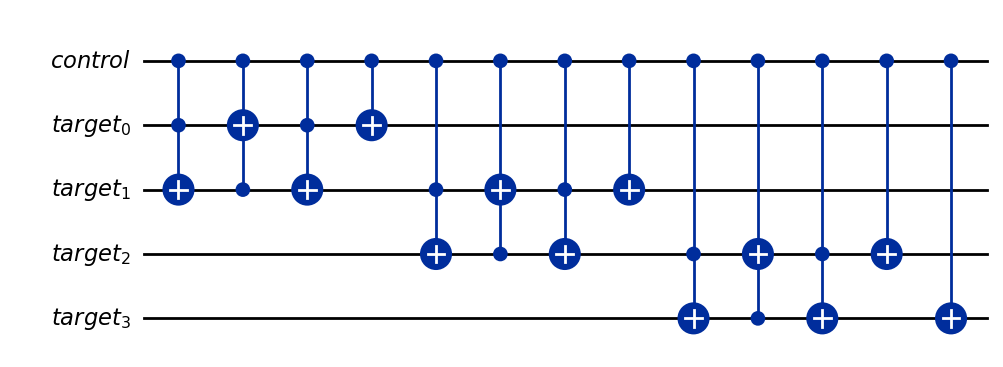

In [4]:
def c_amod15(a, power):
    "Controlled machine that multiplies by a, 'power' times, mod 15."
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("a must be 2, 4, 7, 8, 11, or 13 (coprime to 15)")

    U = QuantumCircuit(4)
    for _ in range(power):
        # each block below is one 'multiply by a mod 15' step,
        # done purely by shuffling and flipping 4 qubits
        if a in [2, 13]:
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3); U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)

    gate = U.to_gate()
    gate.name = f"{a}^{power} mod 15"
    return gate.control()   # make it 'controlled' so a counting qubit can switch it on


# peek at one multiply-machine
c_amod15(7, 1).definition.draw(output="mpl", fold=-1)

## 3. The full circuit — the same three stages as Simon's

This is the punchline. Look at the shape of the circuit and compare it to Simon's:

**Stage 1 — Spread out.** Hadamard gates put the top register (the **counting register**) into superposition — every possible number at once. *Exactly like Simon's stage 1.*

**Stage 2 — Ask the machine.** We run the multiply-machine, controlled by the counting qubits. The rhythm of the machine gets stamped into the quantum state. *This is Simon's stage 2 — call the oracle.*

**Stage 3 — Fold back.** Here is the one real difference. Simon's folds back with Hadamard gates. Shor's folds back with a fancier cousin called the **inverse QFT** (Quantum Fourier Transform). Both do the same *kind* of job — they cause **interference** so that only rhythm-revealing answers survive. The QFT is just a Hadamard that can detect *any* repeating rhythm, not only the mirror-pattern Simon's looks for.

> **The one-sentence summary of this whole notebook:** Simon's finds a hidden *mirror* using Hadamards. Shor's finds a hidden *rhythm* using the QFT. Everything else is the same skeleton.

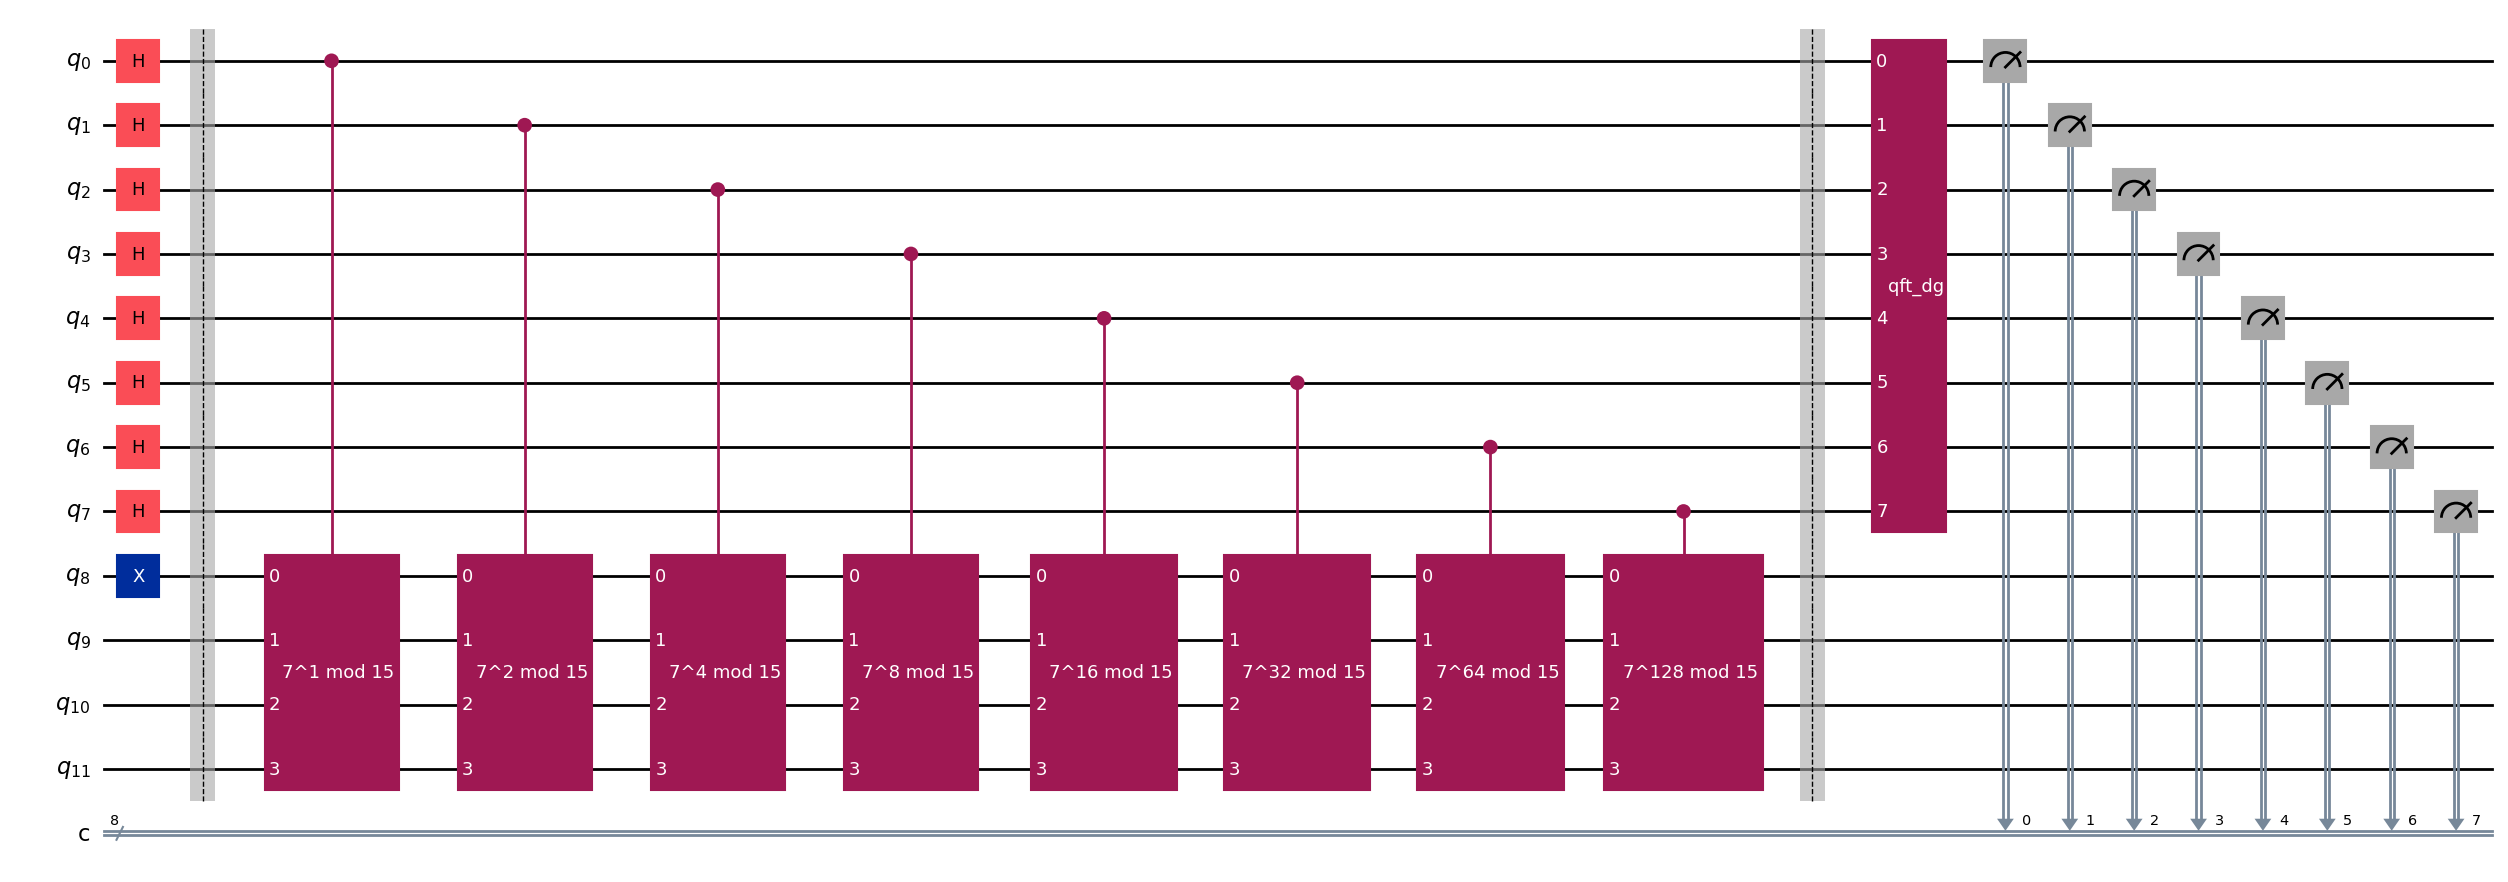

In [5]:
def shor_circuit(a, n_count=8):
    "The full Shor circuit: n_count counting qubits + 4 work qubits."
    qc = QuantumCircuit(n_count + 4, n_count)

    # Stage 1 - spread out (superposition over the counting register)
    for q in range(n_count):
        qc.h(q)

    # start the work register in the state |1>
    qc.x(n_count)
    qc.barrier()

    # Stage 2 - ask the machine, controlled by each counting qubit
    for q in range(n_count):
        qc.append(c_amod15(a, 2**q),
                  [q] + [i + n_count for i in range(4)])
    qc.barrier()

    # Stage 3 - fold back with the inverse QFT, then look
    qc.append(QFTGate(n_count).inverse(), range(n_count))
    qc.measure(range(n_count), range(n_count))

    return qc


A = 7
qc = shor_circuit(A)
qc.draw(output="mpl", fold=-1)

## 4. Run it and read the rhythm

We run the circuit many times. Each run gives back a number. Those numbers cluster around special spots — and the spacing of those spots reveals the period.

More precisely: each measured number, divided by `2^(counting qubits)`, is close to a fraction `something / r`. The bottom of that fraction is the period we want.

Measured outcomes for a = 7:
  00000000   (= 0)   seen 244 times
  01000000   (= 64)   seen 247 times
  10000000   (= 128)   seen 276 times
  11000000   (= 192)   seen 257 times


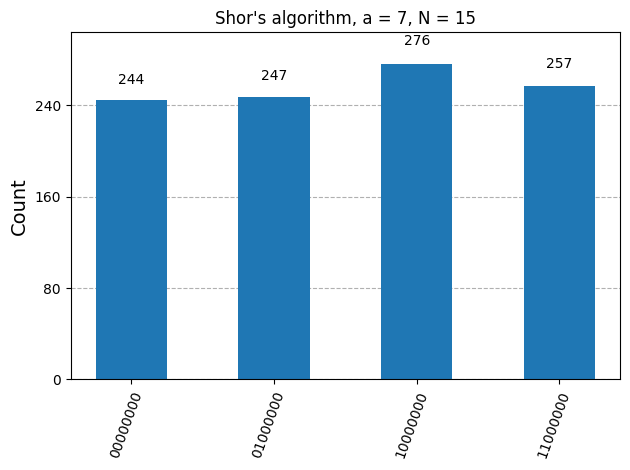

In [6]:
def run_shor(a, n_count=8, shots=1024):
    qc = shor_circuit(a, n_count)
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    return counts


A = 7
counts = run_shor(A)
print(f"Measured outcomes for a = {A}:")
for bits in sorted(counts):
    dec = int(bits, 2)
    print(f"  {bits}   (= {dec})   seen {counts[bits]} times")

plot_histogram(counts, title=f"Shor's algorithm, a = {A}, N = 15")

## 5. Turn each measurement into the period

This is Shor's version of Simon's "classical half." In Simon's, we collected clues and solved equations with Gaussian elimination. Here, we take each measured number and use **continued fractions** — a fancy name for finding the simplest fraction close to a decimal — to read off the period `r`.

The `Fraction(...).limit_denominator(N)` call does all the work: it finds the nicest fraction near our measurement, and the **denominator is the period.**

In [7]:
def measurement_to_period(bits, n_count, N=15):
    "Turn one measured bitstring into a guess for the period r."
    decimal = int(bits, 2)
    phase = decimal / (2 ** n_count)          # a number between 0 and 1
    frac = Fraction(phase).limit_denominator(N)
    return phase, frac, frac.denominator


A = 7
counts = run_shor(A)

print(f"{'measured':<12}{'phase':<10}{'fraction':<12}{'period r'}")
print("-" * 44)
for bits in sorted(counts):
    phase, frac, r = measurement_to_period(bits, 8)
    print(f"{bits:<12}{phase:<10.4f}{str(frac):<12}{r}")

measured    phase     fraction    period r
--------------------------------------------
00000000    0.0000    0           1
01000000    0.2500    1/4         4
10000000    0.5000    1/2         2
11000000    0.7500    3/4         4


Notice the periods that show up: mostly **4** (and sometimes 1 or 2 from the boring `0` measurement, or from a fraction that reduced too far). The winner — the biggest even period that keeps showing up — is `r = 4`, which matches the rhythm we saw by hand in Section 1. 🎉

## 6. From period to factors — the 200-year-old math

Now the quantum part is over. We have the period `r`. Here is the old arithmetic trick that turns `r` into the actual factors:

1. Make sure `r` is **even** (if it's odd, pick a new `a` and try again).
2. Compute two numbers: `a^(r/2) - 1` and `a^(r/2) + 1`.
3. Take the **greatest common divisor (GCD)** of each with `N`. Those GCDs are your factors!

For `a = 7`, `r = 4`:
- `7^2 - 1 = 48`, and `GCD(48, 15) = 3`
- `7^2 + 1 = 50`, and `GCD(50, 15) = 5`

And there it is: **15 = 3 x 5.** The lock is picked.

In [8]:
def factors_from_period(a, r, N=15):
    "Use the period r to recover the factors of N."
    if r % 2 != 0:
        return None, "period is odd - pick a different a and retry"
    x = a ** (r // 2)
    f1 = gcd(x - 1, N)
    f2 = gcd(x + 1, N)
    good = [f for f in (f1, f2) if f not in (1, N)]
    if not good:
        return None, "unlucky guess - pick a different a and retry"
    return good, "success"


A, R = 7, 4
factors, msg = factors_from_period(A, R)
print(f"a = {A}, period r = {R}")
print(f"a^(r/2) - 1 = {A**(R//2) - 1},  gcd with 15 = {gcd(A**(R//2)-1, 15)}")
print(f"a^(r/2) + 1 = {A**(R//2) + 1},  gcd with 15 = {gcd(A**(R//2)+1, 15)}")
print(f"\nFactors of 15: {factors}   ({msg})")

a = 7, period r = 4
a^(r/2) - 1 = 48,  gcd with 15 = 3
a^(r/2) + 1 = 50,  gcd with 15 = 5

Factors of 15: [3, 5]   (success)


## 7. The whole thing, end to end

Let's chain every step together into one function: run the quantum circuit, read the period, and compute the factors — automatically.

In [9]:
def shor_factor(a, n_count=8, shots=1024, N=15):
    "Full Shor's algorithm: quantum period-finding + classical factoring."
    counts = run_shor(a, n_count, shots)

    found = set()
    for bits in counts:
        _, _, r = measurement_to_period(bits, n_count, N)
        factors, status = factors_from_period(a, r, N)
        if factors:
            found.update(factors)

    print(f"a = {a:2d}  ->  factors found: {sorted(found) if found else 'none this run'}")
    return sorted(found)


print("Factoring 15 with several choices of a:\n")
for a in [2, 4, 7, 8, 11, 13]:
    shor_factor(a)

Factoring 15 with several choices of a:

a =  2  ->  factors found: [3, 5]


a =  4  ->  factors found: [3, 5]


a =  7  ->  factors found: [3, 5]
a =  8  ->  factors found: [3, 5]


a = 11  ->  factors found: [3, 5]


a = 13  ->  factors found: [3, 5]


Every good choice of `a` lands on **3 and 5**. Some values (like `a = 11`, whose period is only 2) work through a slightly different path, but the math still delivers the factors. That robustness — many roads to the same answer — is why Shor's algorithm is reliable.

## 8. Exactly what Shor's borrowed from Simon's

This is the question this notebook exists to answer. Here is the honest, side-by-side accounting.

| Ingredient | Simon's algorithm | Shor's algorithm | Borrowed? |
|---|---|---|---|
| **Spread out** (superposition) | Hadamards on the input register | Hadamards on the counting register | ✅ Identical |
| **Ask an oracle** | Vending machine `f(x) = f(x ⊕ s)` | Multiply machine `a^x mod N` | ✅ Same role |
| **Hidden structure** | A secret mirror `s` | A secret rhythm `r` | ✅ Same idea, different shape |
| **Fold back** (interference) | Hadamards again | Inverse **QFT** | ⚠️ Upgraded |
| **Measure = one clue** | Get a `z` with `z · s = 0` | Get a number near `k / r` | ✅ Same philosophy |
| **Finish classically** | Solve equations (Gaussian elimination) | Continued fractions + GCD | ✅ Same two-part template |

### The single most important borrowed idea

> **The quantum computer never hands you the final answer. It hands you one *clue* per run, and a normal computer finishes the job.**

Simon's proved this template works. Shor's took the exact same template and pointed it at a problem the world actually cares about — breaking encryption.

### The one real upgrade: Hadamard → QFT

Simon's uses Hadamard gates to fold back. A Hadamard is perfect for spotting a **mirror** pattern (`x` and `x ⊕ s` are mirror-twins). But a repeating **rhythm** needs a more sensitive detector. That detector is the **Quantum Fourier Transform**. You can even think of the QFT as "a Hadamard that can hear *any* beat, not just a two-beat mirror."

Everything else — the superposition, the oracle, the one-clue-per-run philosophy, the classical cleanup — Shor kept from Simon.

## 9. The big picture — the Hidden Subgroup Problem

Both algorithms are secretly solving the *same master puzzle*, called the **Hidden Subgroup Problem**. You don't need the heavy math — just the shape of it:

> *There is a hidden pattern folded into a function. Use superposition to feel the whole function at once, use interference to cancel everything that doesn't fit the pattern, and read the pattern off the survivors.*

| Algorithm | The hidden pattern | Real-world payoff |
|---|---|---|
| Bernstein–Vazirani | a secret string (read in 1 shot) | teaching example |
| **Simon's** | a secret mirror `s` | first exponential speedup; the template |
| **Shor's** | a secret rhythm `r` | breaks RSA encryption |
| Discrete-log version | a different hidden rhythm | breaks Diffie–Hellman & elliptic-curve crypto |

Simon's was the small, safe laboratory version. Shor's is the same experiment scaled up to something that reshaped cybersecurity. Peter Shor read Simon's paper, recognized the skeleton, and swapped the mirror for a rhythm.

### The honest caveats

- **`N = 15` is a toy.** Real RSA numbers are hundreds of digits. Factoring them needs millions of near-perfect qubits, which don't exist yet. Today's quantum computers can only factor tiny numbers.
- **The multiply-machine here is hand-built** for 15. A general-purpose version is much bigger — that's the hard engineering nobody has finished.
- **This is why "post-quantum" cryptography exists.** The world is already switching to new codes that Shor's algorithm *can't* crack, in case big quantum computers ever arrive.

But the mathematics is settled and correct. The only thing standing between this notebook and broken encryption is engineering — building a big enough, quiet enough quantum computer. And it all rests on the template Simon's algorithm invented.

---

*(c) 2026 David Grunwald. All rights reserved.*